In [6]:
import re
from typing import List, Dict, Any

from unstructured.partition.pdf import partition_pdf
from unstructured.documents.elements import Title


class UniversalHeadingDetector:
    """
    Universal heading detector using:
    1. unstructured document elements
    2. constitution-approved section names
    3. dynamic keyword scoring
    """

    def __init__(self, approved_sections: List[str]):
        self.approved_sections = approved_sections
        self.heading_keywords = self._build_keywords_from_sections(approved_sections)

    def _build_keywords_from_sections(self, sections: List[str]) -> List[str]:
        stop_words = {
            "and", "or", "of", "the", "a", "an", "to", "with",
            "in", "for", "on", "by", "/", "&"
        }

        keywords = set()

        for section in sections:
            cleaned = (
                section.replace("/", " ")
                .replace("&", " ")
                .replace(",", " ")
                .replace("-", " ")
            )

            for word in cleaned.split():
                word = word.lower().strip()

                if word and word not in stop_words and len(word) > 2:
                    keywords.add(word)

        return list(keywords)

    def _normalize_text(self, text: str) -> str:
        text = text.strip()
        text = re.sub(r"\s+", " ", text)
        text = text.replace("–", "-").replace("—", "-")
        return text

    def _is_non_heading_value(self, text: str) -> bool:
        text = text.strip()

        if not text:
            return True

        if re.match(r"^\d+$", text):
            return True

        if re.match(r"^\d{4}$", text):
            return True

        if re.match(r"^[\w\.-]+@[\w\.-]+\.\w+$", text):
            return True

        if re.match(r"^https?://", text):
            return True

        # likely address/value, not heading
        if "," in text and len(text.split()) > 3:
            return True

        return False

    def _matches_constitution_keyword(self, text: str) -> bool:
        text_lower = text.lower()

        return any(keyword in text_lower for keyword in self.heading_keywords)

    def _matches_approved_section(self, text: str) -> bool:
        text_lower = text.lower()

        for section in self.approved_sections:
            section_lower = section.lower()

            if text_lower == section_lower:
                return True

            # partial match: "Certifications & Compliance"
            # can match "Certifications and Accreditations"
            section_words = set(
                re.sub(r"[/,&-]", " ", section_lower).split()
            )
            text_words = set(
                re.sub(r"[/,&-]", " ", text_lower).split()
            )

            common_words = section_words.intersection(text_words)

            if len(common_words) >= 2:
                return True

        return False

    def _is_probable_heading(self, element: Any, next_text: str = "") -> bool:
        text = self._normalize_text(getattr(element, "text", ""))

        if self._is_non_heading_value(text):
            return False

        word_count = len(text.split())

        if word_count > 10:
            return False

        score = 0

        # unstructured detected it as Title
        if isinstance(element, Title):
            score += 2

        # exact/close match with constitution section
        if self._matches_approved_section(text):
            score += 4

        # keyword match from constitution section names
        if self._matches_constitution_keyword(text):
            score += 2

        # title-like text
        if text.istitle():
            score += 1

        # uppercase short heading
        if text.isupper() and word_count <= 6:
            score += 1

        # heading usually followed by longer content
        if next_text and len(next_text.split()) > word_count:
            score += 1

        return score >= 4

    def detect_from_pdf(
        self,
        file_path: str,
        strategy: str = "fast"
    ) -> List[Dict[str, Any]]:

        elements = partition_pdf(
            filename=file_path,
            strategy=strategy
        )

        clean_elements = []

        for element in elements:
            text = self._normalize_text(getattr(element, "text", ""))

            if text:
                clean_elements.append(element)

        blocks = []
        current_heading = "General"
        current_text = []

        for index, element in enumerate(clean_elements):
            text = self._normalize_text(element.text)

            next_text = ""
            if index + 1 < len(clean_elements):
                next_text = self._normalize_text(clean_elements[index + 1].text)

            if self._is_probable_heading(element, next_text):
                if current_text:
                    blocks.append({
                        "heading": current_heading,
                        "text": "\n".join(current_text).strip()
                    })

                current_heading = text
                current_text = []
            else:
                current_text.append(text)

        if current_text:
            blocks.append({
                "heading": current_heading,
                "text": "\n".join(current_text).strip()
            })

        return blocks

In [7]:
APPROVED_SECTIONS = [
    "Company Overview",
    "Company History",
    "Vision, Mission and Values",
    "Core Services / Offerings",
    "Products / Platforms",
    "Sector Experience",
    "Key Capabilities",
    "Technical Expertise",
    "Methodology / Delivery Approach",
    "Project Management Approach",
    "Team Structure",
    "Key Personnel Profiles",
    "Relevant Experience / Case Studies",
    "Client Portfolio",
    "Certifications and Accreditations",
    "Compliance and Regulatory Capability",
    "Quality Assurance Approach",
    "Information Security and Data Protection",
    "Risk Management",
    "Business Continuity and Disaster Recovery",
    "Health, Safety and Wellbeing",
    "Sustainability / ESG",
    "Equality, Diversity and Inclusion",
    "Innovation Capability",
    "Tools, Systems and Infrastructure",
    "Partnership and Supplier Network",
    "Financial Stability",
    "Insurance and Legal Information",
    "Mobilisation Approach",
    "Support and Maintenance Approach",
    "Training and Knowledge Transfer",
    "Reporting and Performance Management",
    "Social Value",
    "References / Testimonials",
    "Unique Value Proposition",
    "Contact and Company Details",
]

detector = UniversalHeadingDetector(APPROVED_SECTIONS)

blocks = detector.detect_from_pdf(
    file_path="bharat_tech_solutions_company_profile 2.pdf",
    strategy="fast"
)

for block in blocks:
    print("\n======================")
    print("HEADING:", block["heading"])
    print("TEXT:", block["text"])

No languages specified, defaulting to English.



HEADING: General
TEXT: Bharat Tech Solutions Private Limited

HEADING: Company Overview
TEXT: Bharat Tech Solutions Private Limited is a leading Indian IT infrastructure and digital transformation company established in 2018. The organization provides endntonend technology solutions for government departments, public sector undertakings (PSUs), and private enterprises across India. The company focuses on enabling secure, scalable, and futurenready IT systems aligned with the Government of India’s Digital India initiative.

HEADING: Company Name
TEXT: Bharat Tech Solutions Private Limited
Established
2018

HEADING: Headquarters
TEXT: Sector 62, Noida, Uttar Pradesh, India

HEADING: Regional Offices
TEXT: Bengaluru, Mumbai, Hyderabad

HEADING: Core Capabilities & Services
TEXT: Installation and maintenance of IPnbased CCTV surveillance systems for smart city and security projects LAN/WAN networking, fiber optic deployment, and enterprise WinFi implementation Cloud migration and hybrid c

### First Phase

In [ ]:
from typing import TypedDict, List, Dict, Any, Optional


class WorkflowState(TypedDict):
    file_path: str
    company_profile_id: str
    file_id: str
    document_name: str

    raw_text: Optional[str]
    clean_text: Optional[str]

    heading_blocks: Optional[List[Dict[str, Any]]]
    chunks: Optional[List[Dict[str, Any]]]
    embedded_chunks: Optional[List[Dict[str, Any]]]

    status: Optional[str]
    current_step: Optional[str]
    error: Optional[str]

### Heading Detector

In [ ]:
from typing import List, Dict, Any


class HeadingDetector:
    KNOWN_HEADINGS = [
        "Company Overview",
        "Company Details",
        "Core Capabilities & Services",
        "Industry Expertise",
        "Certifications & Compliance",
        "Major Clients",
        "Vision & Commitment",
    ]

    def detect(self, text: str) -> List[Dict[str, Any]]:
        lines = [line.strip() for line in text.splitlines() if line.strip()]

        blocks = []
        current_heading = "General"
        current_text = []

        for line in lines:
            if line in self.KNOWN_HEADINGS:
                if current_text:
                    blocks.append({
                        "heading": current_heading,
                        "text": "\n".join(current_text).strip()
                    })

                current_heading = line
                current_text = []
            else:
                current_text.append(line)

        if current_text:
            blocks.append({
                "heading": current_heading,
                "text": "\n".join(current_text).strip()
            })

        return blocks

### Document Cleaner

In [ ]:
import re
import unicodedata


class DocumentCleaner:

    def clean(self, text: str) -> str:
        """
        Universal document cleaning pipeline.
        Works for:
        - PDF text
        - OCR text
        - DOCX extraction
        - scanned documents
        - multilingual Unicode text
        """

        if not text:
            return ""

        # -----------------------------------
        # 1. Normalize unicode characters
        # -----------------------------------
        text = unicodedata.normalize("NFKC", text)

        # -----------------------------------
        # 2. Standardize line endings
        # -----------------------------------
        text = text.replace("\r\n", "\n")
        text = text.replace("\r", "\n")

        # -----------------------------------
        # 3. Remove invisible/control chars
        # -----------------------------------
        text = re.sub(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]", "", text)

        # -----------------------------------
        # 4. Remove excessive spaces/tabs
        # -----------------------------------
        text = re.sub(r"[ \t]+", " ", text)

        # -----------------------------------
        # 5. Remove excessive blank lines
        # -----------------------------------
        text = re.sub(r"\n{3,}", "\n\n", text)

        # -----------------------------------
        # 6. Fix broken unicode replacements
        # -----------------------------------
        replacements = {
            "�": "-",
            "–": "-",
            "—": "-",
            "•": "-",
            "▪": "-",
            " ": " ",  # non-breaking space
        }

        for old, new in replacements.items():
            text = text.replace(old, new)

        # -----------------------------------
        # 7. Remove page artifacts
        # -----------------------------------
        text = re.sub(r"Page\s+\d+\s*(of\s+\d+)?", "", text, flags=re.IGNORECASE)

        # -----------------------------------
        # 8. Remove repeated OCR garbage
        # -----------------------------------
        text = re.sub(r"[^\w\s\n\-\.,:/()&%]", " ", text)

        # -----------------------------------
        # 9. Normalize multiple punctuation
        # -----------------------------------
        text = re.sub(r"\.{2,}", ".", text)
        text = re.sub(r"\-{2,}", "-", text)

        # -----------------------------------
        # 10. Normalize spacing around newlines
        # -----------------------------------
        text = re.sub(r" *\n *", "\n", text)

        # -----------------------------------
        # 11. Final trim
        # -----------------------------------
        text = text.strip()

        return text

### Chunk Classifier

In [ ]:
from typing import List


class ChunkClassifier:
    def classify(self, chunk_text: str, heading: str) -> List[str]:
        text = chunk_text.lower()
        heading = heading.lower()

        sections = []

        if "company overview" in heading:
            sections.append("Company Overview")

        if "company details" in heading:
            sections.extend([
                "Company Overview",
                "Company History",
                "Contact and Company Details"
            ])

        if "core capabilities" in heading or "services" in heading:
            sections.extend([
                "Core Services / Offerings",
                "Key Capabilities",
                "Technical Expertise"
            ])

        if "industry expertise" in heading:
            sections.extend([
                "Sector Experience",
                "Client Portfolio"
            ])

        if "certifications" in heading or "compliance" in heading:
            sections.extend([
                "Certifications and Accreditations",
                "Compliance and Regulatory Capability"
            ])

        if "major clients" in heading:
            sections.extend([
                "Client Portfolio",
                "Relevant Experience / Case Studies",
                "Sector Experience"
            ])

        if "vision" in heading or "commitment" in heading:
            sections.extend([
                "Vision, Mission and Values",
                "Unique Value Proposition",
                "Innovation Capability"
            ])

        if any(x in text for x in ["iso", "msme", "startup india", "gem"]):
            sections.append("Certifications and Accreditations")

        if any(x in text for x in ["iso 27001", "information security", "data protection"]):
            sections.append("Information Security and Data Protection")

        if any(x in text for x in ["cctv", "lan", "wan", "cloud", "software", "erp"]):
            sections.extend([
                "Core Services / Offerings",
                "Technical Expertise",
                "Tools, Systems and Infrastructure"
            ])

        return list(set(sections))

### Embedding Service

In [ ]:
from sentence_transformers import SentenceTransformer


class EmbeddingService:
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        self.model = SentenceTransformer(model_name)

    def embed_text(self, text: str) -> list[float]:
        return self.model.encode(text).tolist()

### Store in  Qdrant

In [ ]:
import uuid
from typing import List, Dict, Any

from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, VectorParams, Distance


class QdrantChunkStore:
    def __init__(
        self,
        collection_name: str = "company_documents",
        host: str = "localhost",
        port: int = 6333,
        vector_size: int = 384
    ):
        self.collection_name = collection_name
        self.client = QdrantClient(host=host, port=port)
        self.vector_size = vector_size

    def create_collection_if_not_exists(self):
        collections = self.client.get_collections().collections
        existing = [c.name for c in collections]

        if self.collection_name not in existing:
            self.client.create_collection(
                collection_name=self.collection_name,
                vectors_config=VectorParams(
                    size=self.vector_size,
                    distance=Distance.COSINE
                )
            )

    def store_chunks(self, embedded_chunks: List[Dict[str, Any]]):
        points = []

        for chunk in embedded_chunks:
            point = PointStruct(
                id=str(uuid.uuid4()),
                vector=chunk["embedding"],
                payload=chunk["payload"]
            )
            points.append(point)

        self.client.upsert(
            collection_name=self.collection_name,
            points=points
        )

        return {
            "stored_count": len(points),
            "collection_name": self.collection_name
        }

### Graph Nodes

In [ ]:
from typing import Dict, Any

# from app.graph.state import WorkflowState
# from app.services.document_cleaner import DocumentCleaner
# from app.services.heading_detector import HeadingDetector
# from app.services.chunk_classifier import ChunkClassifier
# from app.services.embedding_service import EmbeddingService
# from app.services.qdrant_store import QdrantChunkStore


cleaner = DocumentCleaner()
heading_detector = HeadingDetector()
classifier = ChunkClassifier()
embedding_service = EmbeddingService()
qdrant_store = QdrantChunkStore()


def clean_text_node(state: WorkflowState) -> Dict[str, Any]:
    try:
        clean_text = cleaner.clean(state["raw_text"])

        return {
            "clean_text": clean_text,
            "current_step": "text_cleaned",
            "status": "running",
            "error": None
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": f"Clean Text Node Error: {str(e)}"
        }


def detect_headings_node(state: WorkflowState) -> Dict[str, Any]:
    try:
        heading_blocks = heading_detector.detect(state["clean_text"])

        return {
            "heading_blocks": heading_blocks,
            "current_step": "headings_detected",
            "status": "running",
            "error": None
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": f"Heading Detection Node Error: {str(e)}"
        }


def chunk_text_node(state: WorkflowState) -> Dict[str, Any]:
    try:
        chunks = []

        for block_index, block in enumerate(state["heading_blocks"]):
            heading = block["heading"]
            text = block["text"]

            chunks.append({
                "chunk_index": block_index,
                "source_heading": heading,
                "text": text
            })

        return {
            "chunks": chunks,
            "current_step": "chunks_created",
            "status": "running",
            "error": None
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": f"Chunk Text Node Error: {str(e)}"
        }


def classify_chunks_node(state: WorkflowState) -> Dict[str, Any]:
    try:
        classified_chunks = []

        for chunk in state["chunks"]:
            related_sections = classifier.classify(
                chunk_text=chunk["text"],
                heading=chunk["source_heading"]
            )

            chunk["related_sections"] = related_sections
            classified_chunks.append(chunk)

        return {
            "chunks": classified_chunks,
            "current_step": "chunks_classified",
            "status": "running",
            "error": None
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": f"Classify Chunks Node Error: {str(e)}"
        }


def embedding_node(state: WorkflowState) -> Dict[str, Any]:
    try:
        embedded_chunks = []

        for chunk in state["chunks"]:
            embedding = embedding_service.embed_text(chunk["text"])

            payload = {
                "company_profile_id": state["company_profile_id"],
                "file_id": state["file_id"],
                "document_name": state["document_name"],

                "chunk_index": chunk["chunk_index"],
                "source_heading": chunk["source_heading"],
                "text": chunk["text"],
                "related_sections": chunk["related_sections"]
            }

            embedded_chunks.append({
                "embedding": embedding,
                "payload": payload
            })

        return {
            "embedded_chunks": embedded_chunks,
            "current_step": "embeddings_created",
            "status": "running",
            "error": None
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": f"Embedding Node Error: {str(e)}"
        }


def store_qdrant_node(state: WorkflowState) -> Dict[str, Any]:
    try:
        qdrant_store.create_collection_if_not_exists()

        result = qdrant_store.store_chunks(
            embedded_chunks=state["embedded_chunks"]
        )

        return {
            "current_step": "stored_in_qdrant",
            "status": "completed",
            "error": None,
            "qdrant_result": result
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": f"Qdrant Store Node Error: {str(e)}"
        }

### Graph flow

In [ ]:
from langgraph.graph import StateGraph, START, END

from app.graph.state import WorkflowState
from app.graph.nodes import (
    clean_text_node,
    detect_headings_node,
    chunk_text_node,
    classify_chunks_node,
    embedding_node,
    store_qdrant_node
)


builder = StateGraph(WorkflowState)

builder.add_node("clean_text", clean_text_node)
builder.add_node("detect_headings", detect_headings_node)
builder.add_node("chunk_text", chunk_text_node)
builder.add_node("classify_chunks", classify_chunks_node)
builder.add_node("create_embeddings", embedding_node)
builder.add_node("store_qdrant", store_qdrant_node)

builder.add_edge(START, "clean_text")
builder.add_edge("clean_text", "detect_headings")
builder.add_edge("detect_headings", "chunk_text")
builder.add_edge("chunk_text", "classify_chunks")
builder.add_edge("classify_chunks", "create_embeddings")
builder.add_edge("create_embeddings", "store_qdrant")
builder.add_edge("store_qdrant", END)

graph = builder.compile()

### Test Flow

In [ ]:
initial_state = {
    "file_path": "data/company_docs/bharat_tech_solutions_company_profile.pdf",
    "company_profile_id": "6a1039a3181dc0bdd5371d0e",
    "file_id": "6a1039a5181dc0bdd5371d0f",
    "document_name": "bharat_tech_solutions_company_profile.pdf",

    "raw_text": company_text,

    "clean_text": None,
    "heading_blocks": None,
    "chunks": None,
    "embedded_chunks": None,

    "status": "started",
    "current_step": None,
    "error": None
}

result = graph.invoke(initial_state)

print(result["status"])
print(result["current_step"])
print(result.get("error"))

##### Second Phase

In [38]:
from langchain_mistralai import ChatMistralAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv


load_dotenv()

# =====================================================
# Load LLM
# ======================================================
llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.3,
)


In [39]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Dict, Any, Optional
from qdrant_client.models import Filter, FieldCondition, MatchValue


# =====================================================
# State
# =====================================================

from typing import TypedDict, List, Dict, Any, Optional


class WorkflowState(TypedDict):

    # =====================================================
    # Input Fields
    # =====================================================

    company_id: str
    user_name: str
    user_id: str

    constitution: str

    # =====================================================
    # Section Processing
    # =====================================================

    approved_sections: List[str]

    current_section_index: int
    current_section: Optional[str]

    current_section_context: Optional[str]

    # =====================================================
    # Final Generated Output
    # =====================================================

    generated_sections: List[Dict[str, Any]]

    final_output: List[Dict[str, Any]]

    # =====================================================
    # Metadata
    # =====================================================

    current_step: Optional[str]
    status: Optional[str]
    error: Optional[str]



    


# =====================================================
# Approved Sections
# =====================================================

APPROVED_SECTIONS = [
    "Company Overview",
    "Company History",
    "Vision, Mission and Values",
    "Core Services / Offerings",
    "Products / Platforms",
    "Sector Experience",
    "Key Capabilities",
    "Technical Expertise",
    "Methodology / Delivery Approach",
    "Project Management Approach",
    "Team Structure",
    "Key Personnel Profiles",
    "Relevant Experience / Case Studies",
    "Client Portfolio",
    "Certifications and Accreditations",
    "Compliance and Regulatory Capability",
    "Quality Assurance Approach",
    "Information Security and Data Protection",
    "Risk Management",
    "Business Continuity and Disaster Recovery",
    "Health, Safety and Wellbeing",
    "Sustainability / ESG",
    "Equality, Diversity and Inclusion",
    "Innovation Capability",
    "Tools, Systems and Infrastructure",
    "Partnership and Supplier Network",
    "Financial Stability",
    "Insurance and Legal Information",
    "Mobilisation Approach",
    "Support and Maintenance Approach",
    "Training and Knowledge Transfer",
    "Reporting and Performance Management",
    "Social Value",
    "References / Testimonials",
    "Unique Value Proposition",
    "Contact and Company Details"
]

In [53]:
from langchain_core.prompts import ChatPromptTemplate

SECTION_GENERATION_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """
You are a tender-ready company profile section generation agent.

You must generate only ONE section at a time.

STRICT RULES:
- Use only the provided context.
- Do not invent, assume, exaggerate, or add unsupported claims.
- If the context does not contain enough information for the section, return exactly:
SKIP_SECTION
- Do not use placeholders.
- Do not generate generic marketing content.
- Preserve the meaning of the source content.

OUTPUT RULE:
Return ONLY valid JSON object.

JSON FORMAT:
{{
  "SectionName": "string",
  "Summary": "string",
  "Purpose": "string"
}}

Do not include Id. Id will be added by Python.
Do not include markdown.
Do not include explanations.
"""),

    ("human", """
SECTION NAME:
{section_name}

CONSTITUTION RULES:
{constitution}

RELEVANT COMPANY CONTEXT:
{context}

Generate this section now.
""")
])


In [54]:
from qdrant_client import QdrantClient

client = QdrantClient(url="http://localhost:6333")

print(client.get_collections())

collections=[CollectionDescription(name='Global Scrum Generation Constitution'), CollectionDescription(name='CPDocumentsDeepseek_new'), CollectionDescription(name='AgentRegistry'), CollectionDescription(name='CPDocumentsDeepseek'), CollectionDescription(name='Global Scrum')]


In [55]:
from qdrant_client import QdrantClient

from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
    MatchText
)


class QdrantSectionRetriever:

    def __init__(self):
        self.client = QdrantClient(url="http://localhost:6333")
        self.collection_name = "CPDocumentsDeepseek_new"

    def get_chunks_by_section(
        self,
        company_profile_id: str,
        related_section: str,
        limit: int = 5
    ) -> str:

        records, _ = self.client.scroll(
            collection_name=self.collection_name,

            scroll_filter=Filter(
                must=[
                    FieldCondition(
                        key="CompanyProfileId",
                        match=MatchValue(
                            value=company_profile_id
                        )
                    ),

                    FieldCondition(
                        key="RelatedSection",
                        match=MatchText(
                            text=related_section
                        )
                    )
                ]
            ),

            limit=limit,
            with_payload=True
        )

        chunks = [
            point.payload.get("Text", "")
            for point in records
            if point.payload and point.payload.get("Text")
        ]

        return "\n\n".join(chunks)


# =========================================================
# Initialize Retriever
# =========================================================

retriever = QdrantSectionRetriever()


# Retrieve Section Chunks Node
def retrieve_section_chunks_node(state: WorkflowState):

    try:
        print("Running Retrieve Section Chunks Node")

        # Read State
        section_name = state["current_section"]

        company_profile_id = state["company_profile_id"]

        # Retrieve Context
        context = retriever.get_chunks_by_section(
            company_profile_id=company_profile_id,
            related_section=section_name,
            limit=5
        )

        print("Chunks Retrieved Successfully")

        # Return Updated State
        return {
            "current_section_context": context,
            "current_step": f"chunks_retrieved_for_{section_name}",
            "status": "running",
            "error": None
        }

    except Exception as e:

        print(f"Retrieve Section Chunks Error: {str(e)}")

        return {
            "status": "failed",
            "error": f"Retrieve Section Chunks Error: {str(e)}"
        }

In [59]:
import json
from typing import TypedDict, List, Dict, Any, Optional, Annotated
from operator import add

from langgraph.graph import StateGraph, START, END

from app.services.llm_service import llm


# =====================================================
# State
# =====================================================
class WorkflowState(TypedDict):

    company_profile_id: str
    user_name: str
    user_id: str

    constitution: str

    approved_sections: List[str]

    current_section_index: int
    current_section: Optional[str]
    current_section_context: Optional[str]

    generated_sections: Annotated[List[Dict[str, Any]], add]
    final_output: Annotated[List[Dict[str, Any]], add]

    current_step: Optional[str]
    status: Optional[str]
    error: Optional[str]


# =====================================================
# Approved Sections
# =====================================================

APPROVED_SECTIONS = [
    "Company Overview",
    "Company History",
    "Vision, Mission and Values",
    "Core Services / Offerings",
    "Products / Platforms",
    "Sector Experience",
    "Key Capabilities",
    "Technical Expertise",
    "Methodology / Delivery Approach",
    "Project Management Approach",
    "Team Structure",
    "Key Personnel Profiles",
    "Relevant Experience / Case Studies",
    "Client Portfolio",
    "Certifications and Accreditations",
    "Compliance and Regulatory Capability",
    "Quality Assurance Approach",
    "Information Security and Data Protection",
    "Risk Management",
    "Business Continuity and Disaster Recovery",
    "Health, Safety and Wellbeing",
    "Sustainability / ESG",
    "Equality, Diversity and Inclusion",
    "Innovation Capability",
    "Tools, Systems and Infrastructure",
    "Partnership and Supplier Network",
    "Financial Stability",
    "Insurance and Legal Information",
    "Mobilisation Approach",
    "Support and Maintenance Approach",
    "Training and Knowledge Transfer",
    "Reporting and Performance Management",
    "Social Value",
    "References / Testimonials",
    "Unique Value Proposition",
    "Contact and Company Details"
]


# =====================================================
# Retriever
# =====================================================

retriever = QdrantSectionRetriever()


# =====================================================
# Helper Function
# =====================================================

def generate_single_section(state: WorkflowState) -> Dict[str, Any] | None:
    """
    Generates one section using LLM.
    Returns None if section should be skipped.
    """

    section_name = state["current_section"]
    constitution = state["constitution"]
    context = state.get("current_section_context", "")

    formatted_prompt = SECTION_GENERATION_PROMPT.invoke({
        "section_name": section_name,
        "constitution": constitution,
        "context": context
    })

    response = llm.invoke(formatted_prompt)

    content = response.content.strip()

    if content == "SKIP_SECTION":
        return None

    try:
        section_obj = json.loads(content)
    except json.JSONDecodeError:
        raise ValueError(f"Invalid JSON returned by LLM: {content}")

    required_keys = {"SectionName", "Summary", "Purpose"}

    if set(section_obj.keys()) != required_keys:
        raise ValueError(f"Invalid section schema: {section_obj}")

    return section_obj


# =====================================================
# Nodes
# =====================================================

def initialize_section_generation(state: WorkflowState):

    return {
        "approved_sections": APPROVED_SECTIONS,
        "current_section_index": 0,
        "current_section": None,
        "current_section_context": None,
        "generated_sections": [],
        "final_output": [],
        "status": "running",
        "current_step": "section_generation_started",
        "error": None
    }


def select_current_section(state: WorkflowState):

    sections = state["approved_sections"]
    index = state["current_section_index"]

    if index >= len(sections):
        return {
            "current_section": None,
            "current_step": "all_sections_completed",
            "status": "completed"
        }

    section_name = sections[index]

    return {
        "current_section": section_name,
        "current_step": f"processing_section: {section_name}",
        "status": "running"
    }


def retrieve_section_chunks_node(state: WorkflowState):

    try:
        print("Running Retrieve Section Chunks Node")

        section_name = state.get("current_section")
        company_profile_id = state["company_profile_id"]

        if not section_name:
            return {
                "status": "failed",
                "error": "Current section is missing"
            }

        context = retriever.get_chunks_by_section(
            company_profile_id=company_profile_id,
            related_section=section_name,
            limit=5
        )

        print(f"Chunks Retrieved for: {section_name}")

        return {
            "current_section_context": context,
            "current_step": f"chunks_retrieved_for_{section_name}",
            "status": "running",
            "error": None
        }

    except Exception as e:

        return {
            "status": "failed",
            "error": f"Retrieve Section Chunks Error: {str(e)}"
        }


def section_generation_node(state: WorkflowState):

    try:
        generated_sections = list(state.get("generated_sections", []))

        section_name = state["current_section"]
        context = state.get("current_section_context", "")

        if not context or not context.strip():
            return {
                "generated_sections": generated_sections,
                "final_output": generated_sections,
                "current_step": f"{section_name} skipped - no context",
                "status": "running",
                "error": None
            }

        section_obj = generate_single_section(state)

        if section_obj is None:
            return {
                "generated_sections": generated_sections,
                "final_output": generated_sections,
                "current_step": f"{section_name} skipped",
                "status": "running",
                "error": None
            }

        section_obj_with_id = {
            "Id": len(generated_sections) + 1,
            "SectionName": section_obj["SectionName"],
            "Summary": section_obj["Summary"],
            "Purpose": section_obj["Purpose"]
        }

        generated_sections.append(section_obj_with_id)

        return {
            "generated_sections": generated_sections,
            "final_output": generated_sections,
            "current_step": f"{section_name} generated",
            "status": "running",
            "error": None
        }

    except Exception as e:

        return {
            "status": "failed",
            "error": f"Section Generation Node Error: {str(e)}"
        }


def increment_section_index(state: WorkflowState):

    return {
        "current_section_index": state["current_section_index"] + 1,
        "current_section_context": None,
        "current_step": "moving_to_next_section",
        "status": "running"
    }


def should_continue_sections(state: WorkflowState):

    if state.get("status") == "failed":
        return "failed"

    if state["current_section_index"] >= len(state["approved_sections"]):
        return "completed"

    return "continue"


# =====================================================
# Build Graph
# =====================================================

builder = StateGraph(WorkflowState)

builder.add_node("initialize_section_generation", initialize_section_generation)
builder.add_node("select_current_section", select_current_section)
builder.add_node("retrieve_section_chunks", retrieve_section_chunks_node)
builder.add_node("section_generation", section_generation_node)
builder.add_node("increment_section_index", increment_section_index)

builder.add_edge(START, "initialize_section_generation")
builder.add_edge("initialize_section_generation", "select_current_section")
builder.add_edge("select_current_section", "retrieve_section_chunks")
builder.add_edge("retrieve_section_chunks", "section_generation")
builder.add_edge("section_generation", "increment_section_index")

builder.add_conditional_edges(
    "increment_section_index",
    should_continue_sections,
    {
        "continue": "select_current_section",
        "completed": END,
        "failed": END
    }
)

graph = builder.compile()


# =====================================================
# Test Code
# =====================================================


## -----------------------------------
# Read Constitution File
# -----------------------------------
constitution_path = "data/constitutions/02_Constitution_File.md"

with open(constitution_path, "r", encoding="utf-8") as file:
    constitution = file.read()

print("Read Constitution File")



initial_state = {
    "company_profile_id": "6a1039a3181dc0bdd5371d0e",
    "user_name": "Dipesh",
    "user_id": "USR001",

    "constitution": constitution,

    "approved_sections": [],
    "current_section_index": 0,
    "current_section": None,
    "current_section_context": None,

    "generated_sections": [],
    "final_output": [],

    "current_step": None,
    "status": "pending",
    "error": None
}

result = graph.invoke(initial_state)

print("Status:", result["status"])
print("Current Step:", result["current_step"])
print("Error:", result["error"])

print("\nFinal Output:")
print(json.dumps(result["final_output"], indent=4))

Read Constitution File
Running Retrieve Section Chunks Node
Chunks Retrieved for: Company Overview
Running Retrieve Section Chunks Node
Chunks Retrieved for: Company History
Running Retrieve Section Chunks Node
Chunks Retrieved for: Vision, Mission and Values
Running Retrieve Section Chunks Node
Chunks Retrieved for: Core Services / Offerings
Running Retrieve Section Chunks Node
Chunks Retrieved for: Products / Platforms
Running Retrieve Section Chunks Node
Chunks Retrieved for: Sector Experience
Running Retrieve Section Chunks Node
Chunks Retrieved for: Key Capabilities
Running Retrieve Section Chunks Node
Chunks Retrieved for: Technical Expertise
Running Retrieve Section Chunks Node
Chunks Retrieved for: Methodology / Delivery Approach
Running Retrieve Section Chunks Node
Chunks Retrieved for: Project Management Approach
Running Retrieve Section Chunks Node
Chunks Retrieved for: Team Structure
Running Retrieve Section Chunks Node
Chunks Retrieved for: Key Personnel Profiles
Running R

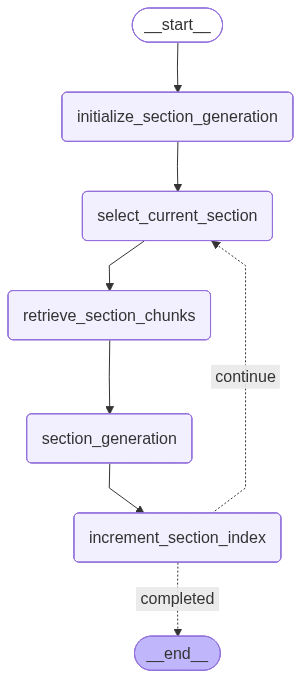

In [57]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:

## -----------------------------------
# Read Constitution File
# -----------------------------------
constitution_path = "data/constitutions/02_Constitution_File.md"

with open(constitution_path, "r", encoding="utf-8") as file:
    constitution = file.read()

print("Read Constitution File")


# -----------------------------------
# Read Specification File
# -----------------------------------
specification_path = "data/constitutions/03_Specification_File.md"

with open(specification_path, "r", encoding="utf-8") as file:
    specification = file.read()

print("Read Specification File")

initial_state = {
    "company_profile_id": "6a1039a3181dc0bdd5371d0e",

    "user_name": "Dipesh",
    "user_id": "USR001",

    "constitution": constitution,

    "approved_sections": [],
    "current_section_index": 0,
    "current_section": None,
    "current_section_context": None,

    "generated_sections": [],
    "final_output": [],

    "current_step": None,
    "status": "pending",
    "error": None
}

Read Constitution File
Read Specification File
